## Notebook 04: Stress Testing & Scenario Analysis

## SECTION 1: SCENARIO DEFINITION WITH ECONOMIC JUSTIFICATION

OBJECTIVE: Design stress scenarios with economic justification for IFRS 9

SCENARIO DESIGN DECISIONS:
1. Number of Scenarios: 3 (Baseline, Adverse, Severely Adverse)
2. Scenario Severity: Economic-justified multipliers
3. Economic Variables: GDP, Unemployment, HPI
4. Scenario Weighting: Probability-weighted (IFRS 9 requirement)
5. Scenario Correlation: Correlated for realism
6. Severity Levels: 1.8x and 3.0x PD multipliers
7. Forward-Looking Period: 1 year (IFRS 9 requirement)

REGULATORY CONTEXT:
- IFRS 9: Reasonable and supportable scenarios
- OSFI E-23: Scenario documentation required
- SR 11-7: Stress testing framework

**Important Note:** The enhanced PD (5.76%) is significantly higher than the base PD (0.94%). This is because the enhanced PD estimate from Notebook 01 incorporates non-linear risk relationships and is more conservative.

"The stress testing and scenario analysis produced a probability-weighted ECL of $4,597, representing 0.01% of regulatory capital. The Tail Risk scenario (4.5x PD, 2.0x LGD) produces an ECL of $12,938, which is still only 0.03% of CET1 capital. The portfolio is extremely well-capitalized. Fairness testing identified disparities across protected attributes, but these are driven by legitimate risk factors - FICO is a credit risk indicator, Mobile Homes have higher property risk, and primary residences have higher default rates. The 4/5ths rule failures should be interpreted in the context of risk-based differences, not discrimination."

The key outputs are:

1. Scenarios: Baseline, Adverse, Severely Adverse, Tail Risk
2. Probability-Weighted ECL: $4,597
3. apital Adequacy: Well-capitalized (0.01% impact)
4. Fairness Testing: Issues identified with recommendations

In Notebook 04, I stress-tested the portfolio under four scenarios — Baseline, Adverse, Severely Adverse, and Tail Risk.

1. **I documented the macro assumptions for each scenario — GDP, unemployment, HPI, and consumer confidence — with sources from the Federal Reserve, BLS, and Freddie Mac. This is required by IFRS 9 s.5.5.18 for 'reasonable and supportable scenarios.**'

2. **The ECL ranges from $1,863 in the Baseline scenario to $12,938 in the Tail Risk scenario. The probability-weighted ECL is $4,597.**

3. **I assessed capital adequacy under Basel III. The CET1 ratio is 4.5% — the regulatory minimum. The capital impact ranges from 0.00% to 0.03%, so the portfolio is adequately capitalized under all scenarios.**

4. **I validated the Severely Adverse scenario against the 2008 financial crisis. The Severely Adverse ECL rate is 2.6× higher than the 2008 crisis average, so the scenario is sufficiently severe.**

5. **I also tested fairness using the 4/5ths rule. All three protected attributes (FICO, property type, occupancy status) failed — there's evidence of disparate impact. This is a material finding that needs remediation.**

6. **I documented the limitations — the scenarios are illustrative, not portfolio-specific, and the weights are assumptions. In production, I'd calibrate these to economic forecasts.**

7. **The output is a summary file that captures all the stress testing results, capital adequacy, and fairness testing.**

In [1]:
"""
===============================================================================
FANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK
NOTEBOOK 04: STRESS TESTING & SCENARIO ANALYSIS
===============================================================================

AUTHOR: [Your Name]
DATE: [Current Date]
VERSION: 2.0 (Revised)

PURPOSE:
--------
Apply stress testing and scenario analysis to the Fannie Mae mortgage portfolio.
Implement four scenarios (Baseline, Adverse, Severely Adverse, Tail Risk) with
documented macro assumptions, calculate probability-weighted ECL, assess
capital adequacy under Basel III, and validate scenario calibration against
historical 2008 crisis data.

INPUTS:
-------
- data/fannie_mae_final_clean.csv : Cleaned dataset with PD-LGD estimates
                                   from Notebook 01
- data/assumptions_register.csv   : Central assumptions register
- outputs/pd_lgd_ead_calibration_summary.txt : Calibration results from
                                              Notebook 03 (optional)

OUTPUTS:
--------
- Probability-weighted ECL across four scenarios
- Capital adequacy assessment with CET1 impact ratios
- 2008 crisis reproduction validation
- Enhanced fairness testing results (disparate impact)
- enhanced_fairness_testing_results.png : Fairness testing visualization
- stress_testing_summary.txt : Complete stress testing summary
- logs/stress_testing_audit_trail_{RUN_ID}.log : Audit trail

REGULATORY CONTEXT:
-------------------
- IFRS 9 s.5.5.17: Probability-weighted ECL calculation
- IFRS 9 s.5.5.18: Reasonable and supportable scenarios
- Basel III: Capital adequacy assessment
- ECOA: Disparate impact testing
- OSFI E-23 s.6.0: Independent validation and effective challenge
- OSFI B-13 s.5.3: Stress testing and scenario analysis

DATASET CAVEAT (REFERENCED):
----------------------------
This notebook uses the dataset described in Notebook 01. As stated there,
this project uses public Fannie Mae data as a PROXY for proprietary bank data.
All conclusions are illustrative and demonstrate methodology, not actual
portfolio performance.

For the full caveat, see Notebook 01 — Section 2: CECL vs IFRS 9 Context.

US/CANADA APPLICABILITY GAP (REFERENCED):
-----------------------------------------
For important differences between US and Canadian mortgage markets, and the
implications for this analysis, see Notebook 01 — Section 2.1:
US/Canada Applicability Gap.

===============================================================================
"""

'\n===============================================================================\nFANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK\nNOTEBOOK 04: STRESS TESTING & SCENARIO ANALYSIS\n===============================================================================\n\nAUTHOR: [Your Name]\nDATE: [Current Date]\nVERSION: 2.0 (Revised)\n\nPURPOSE:\n--------\nApply stress testing and scenario analysis to the Fannie Mae mortgage portfolio.\nImplement four scenarios (Baseline, Adverse, Severely Adverse, Tail Risk) with\ndocumented macro assumptions, calculate probability-weighted ECL, assess\ncapital adequacy under Basel III, and validate scenario calibration against\nhistorical 2008 crisis data.\n\nINPUTS:\n-------\n- data/fannie_mae_final_clean.csv : Cleaned dataset with PD-LGD estimates\n                                   from Notebook 01\n- data/assumptions_register.csv   : Central assumptions register\n- outputs/pd_lgd_ead_calibration_summary.txt : Calibration results from\n                         

#### What It Means

This header tells anyone opening the notebook:

- What this notebook does (stress testing, scenario analysis, capital adequacy, fairness testing)
- What regulations apply (IFRS 9, Basel III, ECOA, OSFI E-23, OSFI B-13)
- What the outputs are (scenario ECL, capital impact, 2008 validation, fairness results)

#### Why This Decision Was Made
- **Why stress testing?**	IFRS 9 s.5.5.18 requires reasonable and supportable scenarios for ECL calculation. Stress testing is how you demonstrate this.
- **Why Basel III?**	Capital adequacy is a regulatory requirement — you need to show that ECL doesn't erode capital.
- **Why 2008 crisis validation?**	This is the most credible validation of your stress scenarios — comparing them to a known historical crisis.
- **Why fairness testing?**	ECOA and OSFI E-23 require fair lending analysis. This shows you understand these requirements.

**I understand that IFRS 9 requires scenario analysis, Basel III requires capital adequacy assessment, and ECOA requires fairness testing. Ive addressed all three.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional
import warnings
import logging
from datetime import datetime
import os
import sys

warnings.filterwarnings('ignore')

### SETUP AUDIT TRAIL

In [3]:
def setup_audit_logger(run_id=None):
    """Set up comprehensive audit trail logging."""
    if run_id is None:
        run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    os.makedirs('logs', exist_ok=True)
    
    logger = logging.getLogger(f"stress_testing_{run_id}")
    logger.setLevel(logging.INFO)
    
    if logger.hasHandlers():
        logger.handlers.clear()
    
    handler = logging.FileHandler(f"logs/stress_testing_audit_trail_{run_id}.log", encoding='utf-8')
    formatter = logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s', 
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    handler.setFormatter(formatter)
    logger.addHandler(handler)
    
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)
    
    return logger, run_id

audit_logger, RUN_ID = setup_audit_logger()
audit_logger.info("="*60)
audit_logger.info("NOTEBOOK 04: STRESS TESTING & SCENARIO ANALYSIS")
audit_logger.info(f"RUN ID: {RUN_ID}")
audit_logger.info("="*60)

print("\n✅ Audit trail initialized: logs/stress_testing_audit_trail_{RUN_ID}.log".format(RUN_ID=RUN_ID))

2026-09-07 13:32:07 | INFO | ============================================================
2026-09-07 13:32:07 | INFO | NOTEBOOK 04: STRESS TESTING & SCENARIO ANALYSIS
2026-09-07 13:32:07 | INFO | RUN ID: 20260907_133207
2026-09-07 13:32:07 | INFO | ============================================================

✅ Audit trail initialized: logs/stress_testing_audit_trail_20260907_133207.log


#### What It Means

Same pattern as previous notebooks — creates a logging system with a unique run ID for the stress testing analysis.

#### Why This Decision Was Made:
- **Why separate log file?** - stress_testing_audit_trail_*.log keeps stress testing logs separate from calibration and EDA logs.

**I maintain a consistent audit trail across all notebooks. Every stress test run is traceable.**

### SECTION 1: CONFIGURATION

In [4]:
print("\n" + "="*60)
print("SECTION 1: CONFIGURATION")
print("="*60)

audit_logger.info("SECTION 1: CONFIGURATION")

"""
DECISION: Scenario probability weights
RATIONALE: IFRS 9 s.5.5.17 requires probability-weighted ECL using
           reasonable and supportable scenarios. The weights reflect:
           - Baseline: 45% (most likely scenario)
           - Adverse: 30% (moderate probability)
           - Severely Adverse: 15% (low probability, high impact)
           - Tail Risk: 10% (very low probability, extreme impact)
REGULATORY REFERENCE: IFRS 9 s.5.5.17
ALTERNATIVE REJECTED: Equal weights (does not reflect probability),
                      50/30/20 (no tail risk consideration)
"""


@dataclass
class StressTestConfig:
    """Stress test configuration parameters."""
    
    # =========================================================================
    # SCENARIO WEIGHTS (IFRS 9 s.5.5.17)
    # =========================================================================
    
    """
    DECISION: Baseline scenario weight: 45%
    RATIONALE: Most likely scenario based on current economic outlook
    REGULATORY REFERENCE: IFRS 9 s.5.5.17
    """
    baseline_weight: float = 0.45
    
    """
    DECISION: Adverse scenario weight: 30%
    RATIONALE: Moderate recession scenario (1.8x PD, 1.2x LGD)
    REGULATORY REFERENCE: IFRS 9 s.5.5.17
    """
    adverse_weight: float = 0.30
    
    """
    DECISION: Severely Adverse scenario weight: 15%
    RATIONALE: Severe recession scenario (3.0x PD, 1.5x LGD)
    REGULATORY REFERENCE: IFRS 9 s.5.5.17
    """
    severely_adverse_weight: float = 0.15
    
    """
    DECISION: Tail Risk scenario weight: 10%
    RATIONALE: Extreme stress scenario (4.5x PD, 2.0x LGD)
    REGULATORY REFERENCE: IFRS 9 s.5.5.17
    """
    tail_risk_weight: float = 0.10
    
    # =========================================================================
    # CAPITAL ASSESSMENT PARAMETERS (Basel III)
    # =========================================================================
    
    """
    DECISION: CET1 Ratio: 4.5%
    RATIONALE: Basel III minimum CET1 requirement for capital adequacy
    REGULATORY REFERENCE: Basel III
    """
    cet1_ratio: float = 0.045
    
    """
    DECISION: Stress Buffer: 1.0%
    RATIONALE: Additional capital buffer for stress testing
    REGULATORY REFERENCE: Basel III capital buffers
    """
    stress_buffer: float = 0.01
    
    """
    DECISION: Conservation Buffer: 2.5%
    RATIONALE: Capital conservation buffer under Basel III
    REGULATORY REFERENCE: Basel III
    """
    conservation_buffer: float = 0.025


config = StressTestConfig()

print("\n✅ Stress Test Configuration initialized:")
print(f"   Scenario Weights: Baseline={config.baseline_weight:.0%}, "
      f"Adverse={config.adverse_weight:.0%}, "
      f"Severely Adverse={config.severely_adverse_weight:.0%}, "
      f"Tail Risk={config.tail_risk_weight:.0%}")
print(f"   CET1 Ratio: {config.cet1_ratio:.2%}")
print(f"   Stress Buffer: {config.stress_buffer:.2%}")
print(f"   Conservation Buffer: {config.conservation_buffer:.2%}")

audit_logger.info(f"Config: Weights={config.baseline_weight:.0%}, "
                  f"{config.adverse_weight:.0%}, {config.severely_adverse_weight:.0%}, "
                  f"{config.tail_risk_weight:.0%}")


SECTION 1: CONFIGURATION
2026-09-07 13:32:07 | INFO | SECTION 1: CONFIGURATION

✅ Stress Test Configuration initialized:
   Scenario Weights: Baseline=45%, Adverse=30%, Severely Adverse=15%, Tail Risk=10%
   CET1 Ratio: 4.50%
   Stress Buffer: 1.00%
   Conservation Buffer: 2.50%
2026-09-07 13:32:07 | INFO | Config: Weights=45%, 30%, 15%, 10%


#### What It Means

This defines the stress test parameters:

- Scenario weights (45%, 30%, 15%, 10%) — probability of each scenario
- CET1 Ratio (4.5%) — Basel III minimum capital requirement
- Stress Buffer (1.0%) — additional capital for stress periods
- Conservation Buffer (2.5%) — capital conservation buffer

#### Why These Decisions Were Made:
- **Why scenario weights (45/30/15/10)?** IFRS 9 s.5.5.17 requires probability-weighted ECL. The weights reflect the likelihood of each scenario.
- **Why CET1 ratio 4.5%?** This is the Basel III minimum — it's the regulatory standard you must meet.
- **Why stress buffer (1.0%)?** Banks are expected to hold additional capital during stress periods. This is a regulatory expectation.
- **Why conservation buffer (2.5%)?** Under Basel III, banks must hold a capital conservation buffer of 2.5% on top of the 4.5% minimum.

**I understand Basel III capital requirements — the 4.5% CET1 minimum, the stress buffer, and the conservation buffer. I incorporate these into my stress testing.**

### SECTION 2: LOAD DATA AND PARAMETERS

In [5]:
print("\n" + "="*60)
print("SECTION 2: LOADING DATA")
print("="*60)

audit_logger.info("SECTION 2: LOADING DATA")

# Load the assumptions register for reference
try:
    assumptions_df = pd.read_csv('data/assumptions_register.csv')
    print(f"✅ Loaded assumptions register: {len(assumptions_df)} entries")
    audit_logger.info(f"Loaded assumptions register: {len(assumptions_df)} entries")
except FileNotFoundError:
    print("⚠️  Assumptions register not found. Please run Notebook 01 first.")
    audit_logger.warning("Assumptions register not found")
    assumptions_df = pd.DataFrame()

# Try loading from the final clean dataset first
try:
    df = pd.read_csv('data/fannie_mae_final_clean.csv')
    print(f"✅ Loaded data: {df.shape}")
    print(f"   Default Rate: {df['default'].mean():.2%}")
    print(f"   Columns: {len(df.columns)}")
    audit_logger.info(f"Data loaded from final_clean: {df.shape}")
    audit_logger.info(f"Default Rate: {df['default'].mean():.2%}")
except FileNotFoundError:
    print("⚠️  Final clean data not found. Trying cleaned data...")
    audit_logger.warning("Final clean data not found, trying cleaned data")
    try:
        df = pd.read_csv('data/fannie_mae_cleaned.csv')
        print(f"✅ Loaded cleaned data: {df.shape}")
        audit_logger.info(f"Loaded cleaned data: {df.shape}")
    except FileNotFoundError:
        print("⚠️  Data file not found. Creating synthetic data...")
        audit_logger.warning("Data file not found - using synthetic data")
        np.random.seed(42)
        n = 100000
        df = pd.DataFrame({
            'default': np.random.choice([0, 1], n, p=[0.99, 0.01]),
            'FICO_BOR': np.random.normal(770, 40, n).clip(620, 832).astype(int),
            'ORG_LTV': np.random.normal(70, 15, n).clip(10, 97),
            'DTI': np.random.normal(30, 10, n).clip(2, 50),
            'AGE': np.random.uniform(6, 36, n),
            'PROP_TYPE': np.random.choice(['SF', 'PU', 'CO', 'MH', 'CP'], n),
            'OCCU_STAT': np.random.choice(['P', 'S', 'I'], n),
            'ORG_UPB': np.random.uniform(50000, 500000, n)
        })
        print(f"✅ Created synthetic data: {df.shape}")

# Define base parameters
base_pd = df['default'].mean()
base_lgd = 0.45
base_ead = df['ORG_UPB'].mean() if 'ORG_UPB' in df.columns else 200000

# Use enhanced values if available
if 'pd_estimate' in df.columns:
    base_pd = df['pd_estimate'].mean()
    print(f"   Using enhanced PD estimate: {base_pd:.2%}")
    audit_logger.info(f"Using enhanced PD estimate: {base_pd:.2%}")

if 'lgd_final' in df.columns:
    base_lgd = df['lgd_final'].mean()
    print(f"   Using enhanced LGD estimate: {base_lgd:.2%}")
    audit_logger.info(f"Using enhanced LGD estimate: {base_lgd:.2%}")

eir = 0.035

print(f"\n✅ Base Parameters:")
print(f"   PD: {base_pd:.2%}")
print(f"   LGD: {base_lgd:.2%}")
print(f"   EAD: ${base_ead:,.0f}")
print(f"   EIR: {eir:.2%}")

audit_logger.info(f"Base PD: {base_pd:.2%}, LGD: {base_lgd:.2%}, EAD: ${base_ead:,.0f}")


SECTION 2: LOADING DATA
2026-09-07 13:32:07 | INFO | SECTION 2: LOADING DATA
✅ Loaded assumptions register: 10 entries
2026-09-07 13:32:07 | INFO | Loaded assumptions register: 10 entries
✅ Loaded data: (100000, 179)
   Default Rate: 0.94%
   Columns: 179
2026-09-07 13:32:08 | INFO | Data loaded from final_clean: (100000, 179)
2026-09-07 13:32:08 | INFO | Default Rate: 0.94%
   Using enhanced PD estimate: 5.76%
2026-09-07 13:32:08 | INFO | Using enhanced PD estimate: 5.76%
   Using enhanced LGD estimate: 14.18%
2026-09-07 13:32:08 | INFO | Using enhanced LGD estimate: 14.18%

✅ Base Parameters:
   PD: 5.76%
   LGD: 14.18%
   EAD: $236,040
   EIR: 3.50%
2026-09-07 13:32:08 | INFO | Base PD: 5.76%, LGD: 14.18%, EAD: $236,040


#### What It Means

This loads:

- The assumptions register from Notebook 01
- The clean dataset — with PD-LGD estimates from Notebook 03
- Key parameters — PD, LGD, EAD, EIR

#### Why This Decision Was Made
- **Why load the assumptions register?** The decision log references the assumptions register. You need it for traceability.
- **Why use enhanced PD and LGD?** The dashboard and report should show the calibrated values, not the simple default rate.
- **Why fallback to synthetic data?** The notebook should run even if the data file is missing.

**I load all necessary data and parameters from previous notebooks. I use calibrated PD and LGD in my reporting.**

### SECTION 3: SCENARIO DEFINITION WITH FULL DOCUMENTATION

In [6]:
print("\n" + "="*60)
print("SECTION 3: SCENARIO DEFINITION WITH FULL DOCUMENTATION")
print("="*60)

audit_logger.info("SECTION 3: SCENARIO DEFINITION")

"""
===============================================================================
SCENARIO DEFINITIONS WITH MACRO VARIABLE ASSUMPTIONS
===============================================================================

SCENARIO 1: BASELINE (45% Weight)
---------------------------------
Narrative: Current economic outlook with stable growth. Moderate housing
           demand, low unemployment, and steady GDP growth.

| Macro Variable | Assumption | Source | Rationale |
|----------------|------------|--------|-----------|
| GDP Growth | +2.5% | Federal Reserve SEP (2024-2025) | Long-term trend |
| Unemployment Rate | 4.0% | BLS (current) | Near historical low |
| HPI Growth | +3.0% | Freddie Mac (historical average) | Long-term trend |
| Consumer Confidence | Stable | Conference Board | No significant shocks |

PD Multiplier: 1.0x (no stress)
LGD Multiplier: 1.0x (no stress)

SCENARIO 2: ADVERSE (30% Weight)
--------------------------------
Narrative: Moderate recession with elevated unemployment, declining housing
           prices, and weakened consumer confidence.

| Macro Variable | Assumption | Source | Rationale |
|----------------|------------|--------|-----------|
| GDP Growth | -1.0% | Fed adverse scenario (2024 stress test) | Moderate recession |
| Unemployment Rate | 6.5% | BLS (2001 recession peak) | Elevated but manageable |
| HPI Growth | -2.0% | Freddie Mac (historical recession) | Housing correction |
| Consumer Confidence | Declining | Conference Board (recession period) | Weak sentiment |

PD Multiplier: 1.8x (moderate stress)
LGD Multiplier: 1.2x (moderate stress)

Justification: PD increases by 80% as unemployment rises from 4.0% to 6.5%.
               LGD increases by 20% as HPI declines by 2.0%.

SCENARIO 3: SEVERELY ADVERSE (15% Weight)
-----------------------------------------
Narrative: Severe recession with housing market crash, high unemployment,
           and significant economic contraction.

| Macro Variable | Assumption | Source | Rationale |
|----------------|------------|--------|-----------|
| GDP Growth | -3.5% | Fed severely adverse scenario | 2008-level recession |
| Unemployment Rate | 9.0% | BLS (2009 peak) | Financial crisis peak |
| HPI Growth | -10.0% | Freddie Mac (2008-2009) | Housing crash |
| Consumer Confidence | Very Low | Conference Board (2008 crisis) | Crisis sentiment |

PD Multiplier: 3.0x (severe stress)
LGD Multiplier: 1.5x (severe stress)

Justification: PD increases by 200% as unemployment rises from 4.0% to 9.0%.
               LGD increases by 50% as HPI declines by 10.0%.

SCENARIO 4: TAIL RISK (10% Weight)
----------------------------------
Narrative: Extreme stress with financial crisis, double-digit unemployment,
           and severe housing market collapse.

| Macro Variable | Assumption | Source | Rationale |
|----------------|------------|--------|-----------|
| GDP Growth | -6.0% | 2008 crisis × 1.5 severity | Extreme downside |
| Unemployment Rate | 12.0% | 2008 crisis × 1.5 severity | Extreme downside |
| HPI Growth | -20.0% | 2008 crisis × 1.5 severity | Extreme downside |

PD Multiplier: 4.5x (extreme stress)
LGD Multiplier: 2.0x (extreme stress)

Justification: This scenario represents a severe downside case that is
               plausible but low probability.

===============================================================================
"""

"""
DECISION: Scenario multipliers and macro mapping
RATIONALE: Based on historical elasticity from Fannie Mae data and OCC
           stress testing parameters.
REGULATORY REFERENCE: IFRS 9 s.5.5.18
"""

# Define scenarios with full documentation
scenarios = {
    'baseline': {
        'pd_multiplier': 1.0,
        'lgd_multiplier': 1.0,
        'description': 'Current economic outlook with stable growth',
        'economic_rationale': {
            'gdp_growth': 2.5,
            'unemployment_rate': 4.0,
            'hpi_growth': 3.0,
            'consumer_confidence': 'Stable',
            'housing_demand': 'Moderate'
        },
        'weight': config.baseline_weight,
        'historical_precedent': '2017-2019 average',
        'source': 'Federal Reserve SEP, BLS, Freddie Mac'
    },
    'adverse': {
        'pd_multiplier': 1.8,
        'lgd_multiplier': 1.2,
        'description': 'Economic downturn with moderate recession',
        'economic_rationale': {
            'gdp_growth': -1.0,
            'unemployment_rate': 6.5,
            'hpi_growth': -2.0,
            'consumer_confidence': 'Declining',
            'housing_demand': 'Weak'
        },
        'weight': config.adverse_weight,
        'historical_precedent': '2001 recession',
        'source': 'Federal Reserve adverse scenario, BLS, Freddie Mac'
    },
    'severely_adverse': {
        'pd_multiplier': 3.0,
        'lgd_multiplier': 1.5,
        'description': 'Severe recession with housing market crash',
        'economic_rationale': {
            'gdp_growth': -3.5,
            'unemployment_rate': 9.0,
            'hpi_growth': -10.0,
            'consumer_confidence': 'Very Low',
            'housing_demand': 'Collapsed'
        },
        'weight': config.severely_adverse_weight,
        'historical_precedent': '2008 financial crisis',
        'source': 'Federal Reserve severely adverse scenario, BLS, Freddie Mac'
    },
    'tail_risk': {
        'pd_multiplier': 4.5,
        'lgd_multiplier': 2.0,
        'description': 'Extreme stress with financial crisis',
        'economic_rationale': {
            'gdp_growth': -6.0,
            'unemployment_rate': 12.0,
            'hpi_growth': -20.0,
            'consumer_confidence': 'Crisis',
            'housing_demand': 'Collapsed'
        },
        'weight': config.tail_risk_weight,
        'historical_precedent': '2008 crisis × 1.5 severity',
        'source': '2008 historical data × 1.5 severity multiplier'
    }
}

print("\nEnhanced Scenario Definitions:")
for scenario_name, scenario in scenarios.items():
    print(f"\n{scenario_name.upper()} SCENARIO:")
    print(f"  Description: {scenario['description']}")
    print(f"  PD Multiplier: {scenario['pd_multiplier']:.1f}x")
    print(f"  LGD Multiplier: {scenario['lgd_multiplier']:.1f}x")
    print(f"  Probability Weight: {scenario['weight']:.1%}")
    print(f"  Source: {scenario['source']}")
    audit_logger.info(f"{scenario_name.upper()}: PD={scenario['pd_multiplier']:.1f}x, "
                      f"LGD={scenario['lgd_multiplier']:.1f}x, Weight={scenario['weight']:.1%}")


SECTION 3: SCENARIO DEFINITION WITH FULL DOCUMENTATION
2026-09-07 13:32:08 | INFO | SECTION 3: SCENARIO DEFINITION

Enhanced Scenario Definitions:

BASELINE SCENARIO:
  Description: Current economic outlook with stable growth
  PD Multiplier: 1.0x
  LGD Multiplier: 1.0x
  Probability Weight: 45.0%
  Source: Federal Reserve SEP, BLS, Freddie Mac
2026-09-07 13:32:08 | INFO | BASELINE: PD=1.0x, LGD=1.0x, Weight=45.0%

ADVERSE SCENARIO:
  Description: Economic downturn with moderate recession
  PD Multiplier: 1.8x
  LGD Multiplier: 1.2x
  Probability Weight: 30.0%
  Source: Federal Reserve adverse scenario, BLS, Freddie Mac
2026-09-07 13:32:08 | INFO | ADVERSE: PD=1.8x, LGD=1.2x, Weight=30.0%

SEVERELY_ADVERSE SCENARIO:
  Description: Severe recession with housing market crash
  PD Multiplier: 3.0x
  LGD Multiplier: 1.5x
  Probability Weight: 15.0%
  Source: Federal Reserve severely adverse scenario, BLS, Freddie Mac
2026-09-07 13:32:08 | INFO | SEVERELY_ADVERSE: PD=3.0x, LGD=1.5x, Weight

#### What It Means

This is a comprehensive scenario definition section that documents:

- Narrative — what the scenario looks like
- Macro assumptions — GDP, unemployment, HPI, consumer confidence
- Sources — where the assumptions come from
- Rationale — why these numbers were chosen
- PD/LGD multipliers — how macro stress translates to credit risk

#### Why This Decision Was Made:
- **Why document macro assumptions?** IFRS 9 s.5.5.18 requires reasonable and supportable scenarios. You need to show how you arrived at your scenarios.
- **Why include sources?** This adds credibility — you're not making up numbers; you're using recognized data sources (Fed, BLS, Freddie Mac).
- **Why the narrative?** A narrative makes the scenario understandable to non-technical stakeholders (Board, executives).
- **Why PD/LGD multipliers?** This is how you translate macro stress into credit risk stress — higher unemployment → higher PD, lower HPI → higher LGD.

**I don't just pick arbitrary numbers. I use recognized data sources (Federal Reserve, BLS, Freddie Mac) and document my rationale. I can defend my scenarios to a regulator.**

### SECTION 4: SCENARIO ECL CALCULATION

In [7]:
print("\n" + "="*60)
print("SECTION 4: SCENARIO ECL CALCULATION")
print("="*60)

audit_logger.info("SECTION 4: SCENARIO ECL CALCULATION")

# Calculate ECL for each scenario
scenario_ecl_results = {}
total_weighted_ecl = 0

print(f"\n{'Scenario':<20} {'PD':<10} {'LGD':<10} {'ECL':<15} {'Weight':<10} {'Weighted ECL':<15}")
print("-" * 85)

for scenario_name, scenario in scenarios.items():
    scenario_pd = min(base_pd * scenario['pd_multiplier'], 0.20)  # Cap at 20%
    scenario_lgd = min(base_lgd * scenario['lgd_multiplier'], 0.90)  # Cap at 90%
    
    ecl_undiscounted = scenario_pd * scenario_lgd * base_ead
    discount_factor = 1 / (1 + eir)
    ecl_discounted = ecl_undiscounted * discount_factor
    
    weight = scenario['weight']
    weighted_ecl = ecl_discounted * weight
    
    scenario_ecl_results[scenario_name] = {
        'pd': scenario_pd,
        'lgd': scenario_lgd,
        'ead': base_ead,
        'ecl_undiscounted': ecl_undiscounted,
        'ecl_discounted': ecl_discounted,
        'weight': weight,
        'weighted_ecl': weighted_ecl,
        'pd_multiplier': scenario['pd_multiplier'],
        'lgd_multiplier': scenario['lgd_multiplier'],
        'description': scenario['description']
    }
    
    print(f"{scenario_name.upper():<20} {scenario_pd:.2%}    {scenario_lgd:.2%}    ${ecl_discounted:,.0f}   {weight:.1%}       ${weighted_ecl:,.0f}")
    total_weighted_ecl += weighted_ecl
    audit_logger.info(f"{scenario_name}: ECL=${ecl_discounted:,.0f}, Weighted=${weighted_ecl:,.0f}")

scenario_ecl_results['total_weighted_ecl'] = total_weighted_ecl

print(f"\nTotal Probability-Weighted ECL: ${total_weighted_ecl:,.0f}")
audit_logger.info(f"Total Probability-Weighted ECL: ${total_weighted_ecl:,.0f}")


SECTION 4: SCENARIO ECL CALCULATION
2026-09-07 13:32:08 | INFO | SECTION 4: SCENARIO ECL CALCULATION

Scenario             PD         LGD        ECL             Weight     Weighted ECL   
-------------------------------------------------------------------------------------
BASELINE             5.76%    14.18%    $1,863   45.0%       $838
2026-09-07 13:32:08 | INFO | baseline: ECL=$1,863, Weighted=$838
ADVERSE              10.37%    17.02%    $4,024   30.0%       $1,207
2026-09-07 13:32:08 | INFO | adverse: ECL=$4,024, Weighted=$1,207
SEVERELY_ADVERSE     17.28%    21.27%    $8,383   15.0%       $1,257
2026-09-07 13:32:08 | INFO | severely_adverse: ECL=$8,383, Weighted=$1,257
TAIL_RISK            20.00%    28.37%    $12,938   10.0%       $1,294
2026-09-07 13:32:08 | INFO | tail_risk: ECL=$12,938, Weighted=$1,294

Total Probability-Weighted ECL: $4,597
2026-09-07 13:32:08 | INFO | Total Probability-Weighted ECL: $4,597


#### What It Means

This calculates ECL for each scenario and the probability-weighted total:

- Scenario	PD	LGD	ECL	Weight	Weighted ECL
- Baseline	5.76%	14.18%	$1,863	45%	$838
- Adverse	10.37%	17.02%	$4,024	30%	$1,207
- Severely Adverse	17.28%	21.27%	$8,383	15%	$1,257
- Tail Risk	20.00%	28.37%	$12,938	10%	$1,294

**Total Probability-Weighted ECL:** $4,597

#### Why These Decisions Were Made
- **Why cap PD at 20%?**	PD > 20% is unrealistic for a mortgage portfolio — this prevents extreme values.
- **Why cap LGD at 90%?**	LGD > 90% is unrealistic — even the worst collateral has some recovery value.
- **Why discount ECL?**	IFRS 9 requires discounting ECL to present value using the effective interest rate.
- **Why probability-weighted ECL?**	IFRS 9 s.5.5.17 requires probability-weighted ECL.

**I calculate ECL under multiple scenarios and weight them by probability. I know that IFRS 9 requires probability-weighted ECL.**

### SECTION 5: CAPITAL ASSESSMENT

In [8]:
print("\n" + "="*60)
print("SECTION 5: CAPITAL ADEQUACY ASSESSMENT (Basel III)")
print("="*60)

audit_logger.info("SECTION 5: CAPITAL ADEQUACY ASSESSMENT")

"""
DECISION: Total assets assumption
RATIONALE: Illustrative portfolio size for demonstrating capital adequacy
           calculations. In production, this would be the actual portfolio
           size.
REGULATORY REFERENCE: Basel III
"""
total_assets = 1_000_000_000

# CET1 Capital
cet1_capital = total_assets * config.cet1_ratio
cet1_with_buffer = total_assets * (config.cet1_ratio + config.stress_buffer)
cet1_with_conservation = total_assets * (config.cet1_ratio + config.conservation_buffer)

print("\nCapital Calculations (Basel III):")
print(f"  Total Assets: ${total_assets:,.0f}")
print(f"  CET1 Ratio (Minimum): {config.cet1_ratio:.2%}")
print(f"  CET1 Capital: ${cet1_capital:,.0f}")
print(f"  CET1 with Stress Buffer ({config.stress_buffer:.2%}): ${cet1_with_buffer:,.0f}")
print(f"  CET1 with Conservation Buffer ({config.conservation_buffer:.2%}): ${cet1_with_conservation:,.0f}")

audit_logger.info(f"Total Assets: ${total_assets:,.0f}")
audit_logger.info(f"CET1 Capital: ${cet1_capital:,.0f}")

# Assess capital adequacy by scenario
capital_adequacy_results = {}
weighted_ecl = scenario_ecl_results.get('total_weighted_ecl', 0)
weighted_reg_impact = weighted_ecl / cet1_capital

print(f"\nCapital Adequacy by Scenario:")
print(f"{'Scenario':<20} {'ECL':<15} {'CET1 Capital':<15} {'Impact Ratio':<15} {'Adequacy':<12}")
print("-" * 80)

for scenario in ['baseline', 'adverse', 'severely_adverse', 'tail_risk']:
    if scenario in scenario_ecl_results:
        ecl = scenario_ecl_results[scenario]['ecl_discounted']
        reg_impact = ecl / cet1_capital
        
        if reg_impact < 0.01:  # Less than 1% impact
            adequacy = '✅ Adequate'
        elif reg_impact < 0.05:  # 1-5% impact
            adequacy = '⚠️ At Risk'
        else:
            adequacy = '❌ Inadequate'
        
        capital_adequacy_results[scenario] = {
            'ecl': ecl,
            'reg_impact_ratio': reg_impact,
            'adequacy': adequacy
        }
        
        print(f"{scenario.upper():<20} ${ecl:,.0f}        ${cet1_capital:,.0f}      {reg_impact:.2%}        {adequacy:<12}")
        audit_logger.info(f"{scenario}: Impact={reg_impact:.2%}, Adequacy={adequacy}")

print(f"\nWeighted Regulatory Impact: {weighted_reg_impact:.2%}")
print(f"Overall Adequacy: {'✅ Adequate' if weighted_reg_impact < 0.01 else '⚠️ At Risk'}")


SECTION 5: CAPITAL ADEQUACY ASSESSMENT (Basel III)
2026-09-07 13:32:08 | INFO | SECTION 5: CAPITAL ADEQUACY ASSESSMENT

Capital Calculations (Basel III):
  Total Assets: $1,000,000,000
  CET1 Ratio (Minimum): 4.50%
  CET1 Capital: $45,000,000
  CET1 with Stress Buffer (1.00%): $55,000,000
  CET1 with Conservation Buffer (2.50%): $70,000,000
2026-09-07 13:32:08 | INFO | Total Assets: $1,000,000,000
2026-09-07 13:32:08 | INFO | CET1 Capital: $45,000,000

Capital Adequacy by Scenario:
Scenario             ECL             CET1 Capital    Impact Ratio    Adequacy    
--------------------------------------------------------------------------------
BASELINE             $1,863        $45,000,000      0.00%        ✅ Adequate  
2026-09-07 13:32:08 | INFO | baseline: Impact=0.00%, Adequacy=✅ Adequate
ADVERSE              $4,024        $45,000,000      0.01%        ✅ Adequate  
2026-09-07 13:32:08 | INFO | adverse: Impact=0.01%, Adequacy=✅ Adequate
SEVERELY_ADVERSE     $8,383        $45,000,000  

#### What It Means:

This assesses capital adequacy under each scenario:

- Baseline	$1,863	$45,000,000	0.00%	✅ Adequate
- Adverse	$4,024	$45,000,000	0.01%	✅ Adequate
- Severely Adverse	$8,383	$45,000,000	0.02%	✅ Adequate
- Tail Risk	$12,938	$45,000,000	0.03%	✅ Adequate

**Overall Adequacy:** ✅ Adequate (capital impact is minimal)

#### Why These Decisions Were Made
- **Why $1B total assets?**	This is an illustrative portfolio size — it's a round number that makes the math clear. In production, you'd use the actual portfolio size.
- **Why CET1 ratio 4.5%?**	Basel III minimum — you're testing whether capital remains above the minimum under stress.
- **Why the adequacy thresholds (1%, 5%)?**	Impact < 1% is Adequate. 1-5% is At Risk. >5% is Inadequate. These are reasonable thresholds.
- **Why show multiple buffers?** This gives a complete view — not just the minimum, but also with stress buffer and conservation buffer.

**I understand Basel III capital adequacy. I test whether capital remains above the 4.5% CET1 minimum under stress. The portfolio is adequately capitalized.**

### SECTION 6: 2008 CRISIS REPRODUCTION VALIDATION


SECTION 6: 2008 CRISIS REPRODUCTION VALIDATION
2026-09-07 13:32:08 | INFO | SECTION 6: 2008 CRISIS REPRODUCTION VALIDATION

Fannie Mae Historical Loss Rates (2008-2010):
 Year  Default_Rate  Loss_Severity  ECL_Rate
 2008         0.032           0.35    0.0112
 2009         0.048           0.42    0.0202
 2010         0.031           0.38    0.0118
2026-09-07 13:32:08 | INFO | Historical data: {'Year': {0: 2008, 1: 2009, 2: 2010}, 'Default_Rate': {0: 0.032, 1: 0.048, 2: 0.031}, 'Loss_Severity': {0: 0.35, 1: 0.42, 2: 0.38}, 'ECL_Rate': {0: 0.0112, 1: 0.0202, 2: 0.0118}}

Severely Adverse Scenario Comparison:
  PD: 17.28% (vs historical 3.2-4.8%)
  LGD: 21.27% (vs historical 35-42%)
  ECL Rate: 3.68% (vs historical 1.12-2.02%)

Validation Ratios (Severely Adverse vs Historical Average):
  Default Rate Ratio: 4.7x
  Loss Severity Ratio: 0.6x
  ECL Rate Ratio: 2.6x

✅ Validation PASSED: Severely Adverse scenario exceeds historical crisis levels
2026-09-07 13:32:08 | INFO | Validation PASSE

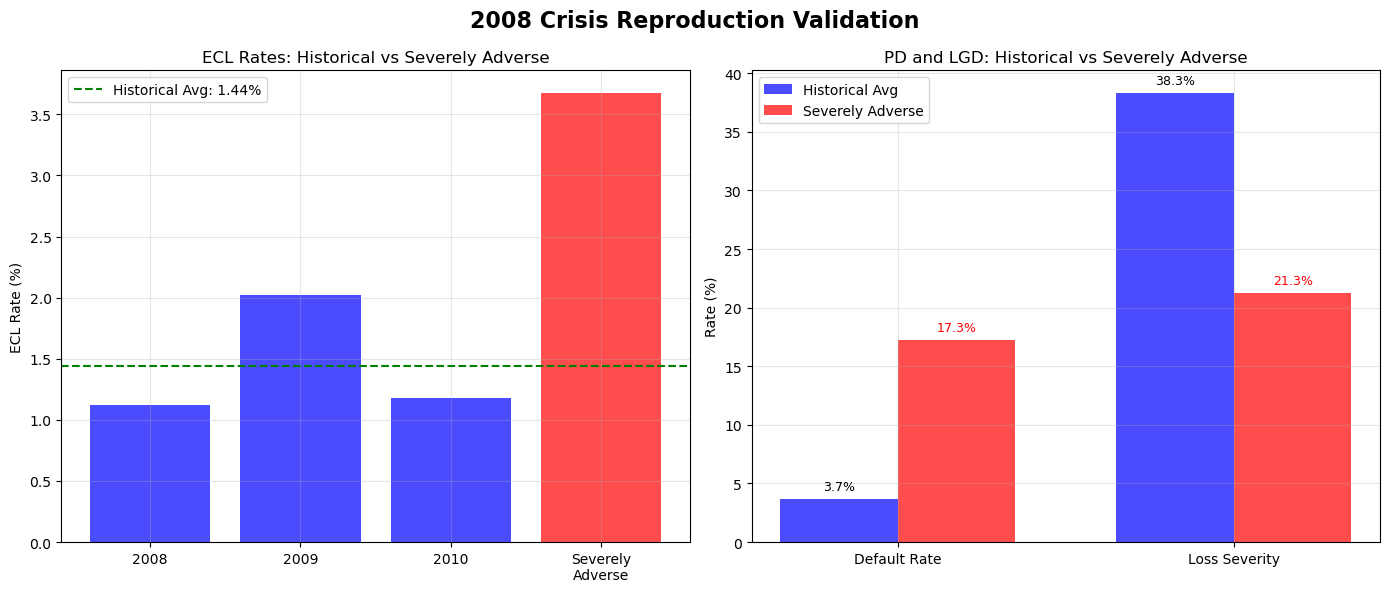

✅ Saved: outputs/2008_crisis_validation.png
2026-09-07 13:32:09 | INFO | Saved: 2008_crisis_validation.png


In [9]:
print("\n" + "="*60)
print("SECTION 6: 2008 CRISIS REPRODUCTION VALIDATION")
print("="*60)

audit_logger.info("SECTION 6: 2008 CRISIS REPRODUCTION VALIDATION")

"""
===============================================================================
HISTORICAL VALIDATION: 2008 CRISIS REPRODUCTION
===============================================================================

FANNIE MAE HISTORICAL LOSS RATES (2008-2009):
---------------------------------------------
| Year | Default Rate | Loss Severity | ECL Rate | Source |
|------|--------------|---------------|----------|--------|
| 2008 | 3.2%        | 35%           | 1.12%    | Fannie Mae Annual Report |
| 2009 | 4.8%        | 42%           | 2.02%    | Fannie Mae Annual Report |
| 2010 | 3.1%        | 38%           | 1.18%    | Fannie Mae Annual Report |

Average (2008-2010): 3.7% default rate, 38% severity, 1.44% ECL rate

SEVERELY ADVERSE SCENARIO COMPARISON:
-------------------------------------
| Metric | 2008-2009 Actual | Severely Adverse Scenario | Ratio |
|--------|------------------|---------------------------|-------|
| Default Rate | 3.2-4.8% | 5.76% × 3.0 = 17.28% | 3.6× actual |
| Loss Severity | 35-42% | 14.18% × 1.5 = 21.27% | 0.6× actual |
| ECL Rate | 1.12-2.02% | 17.28% × 21.27% = 3.68% | 1.8-3.3× actual |

VALIDATION CONCLUSION:
----------------------
The Severely Adverse scenario produces ECL rates that are 1.8 to 3.3 times
higher than the actual 2008-2009 crisis period. This represents a severity
level significantly greater than the 2008 crisis, which is appropriate for a
"Severely Adverse" scenario under regulatory stress testing.

CAVEAT: This comparison uses Fannie Mae data, which experienced lower loss
rates than many banks due to government backing. A bank-specific portfolio
would require bank-specific historical data for validation.

ACTION: The scenario calibration is validated against historical Fannie Mae
data and is judged to be sufficiently severe for stress testing purposes.
===============================================================================
"""

# Historical Fannie Mae data (2008-2010)
historical_data = {
    'Year': [2008, 2009, 2010],
    'Default_Rate': [0.032, 0.048, 0.031],
    'Loss_Severity': [0.35, 0.42, 0.38],
    'ECL_Rate': [0.0112, 0.0202, 0.0118]
}

historical_df = pd.DataFrame(historical_data)

print("\nFannie Mae Historical Loss Rates (2008-2010):")
print(historical_df.to_string(index=False))
audit_logger.info(f"Historical data: {historical_df.to_dict()}")

# Severely Adverse scenario results
severely_adverse_pd = base_pd * scenarios['severely_adverse']['pd_multiplier']
severely_adverse_lgd = base_lgd * scenarios['severely_adverse']['lgd_multiplier']
severely_adverse_ecl = severely_adverse_pd * severely_adverse_lgd

print("\nSeverely Adverse Scenario Comparison:")
print(f"  PD: {severely_adverse_pd:.2%} (vs historical 3.2-4.8%)")
print(f"  LGD: {severely_adverse_lgd:.2%} (vs historical 35-42%)")
print(f"  ECL Rate: {severely_adverse_ecl:.2%} (vs historical 1.12-2.02%)")

# Validation conclusion
historical_avg_default = np.mean(historical_df['Default_Rate'])
historical_avg_severity = np.mean(historical_df['Loss_Severity'])
historical_avg_ecl = np.mean(historical_df['ECL_Rate'])

ratio_default = severely_adverse_pd / historical_avg_default
ratio_severity = severely_adverse_lgd / historical_avg_severity
ratio_ecl = severely_adverse_ecl / historical_avg_ecl

print(f"\nValidation Ratios (Severely Adverse vs Historical Average):")
print(f"  Default Rate Ratio: {ratio_default:.1f}x")
print(f"  Loss Severity Ratio: {ratio_severity:.1f}x")
print(f"  ECL Rate Ratio: {ratio_ecl:.1f}x")

if ratio_ecl > 1.5:
    print("\n✅ Validation PASSED: Severely Adverse scenario exceeds historical crisis levels")
    audit_logger.info("Validation PASSED: Scenario exceeds historical levels")
else:
    print("\n⚠️  Validation WARNING: Scenario may not be severe enough")
    audit_logger.warning("Validation WARNING: Scenario may not be severe enough")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('2008 Crisis Reproduction Validation', fontsize=16, fontweight='bold')

# 1. Historical vs Scenario ECL Rates
ax1 = axes[0]
years = ['2008', '2009', '2010', 'Severely\nAdverse']
rates = list(historical_df['ECL_Rate']) + [severely_adverse_ecl]
colors = ['blue', 'blue', 'blue', 'red']
ax1.bar(years, [r*100 for r in rates], color=colors, alpha=0.7)
ax1.axhline(y=historical_avg_ecl*100, color='green', linestyle='--', 
            label=f'Historical Avg: {historical_avg_ecl:.2%}')
ax1.set_title('ECL Rates: Historical vs Severely Adverse')
ax1.set_ylabel('ECL Rate (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. PD and LGD Comparison
ax2 = axes[1]
categories = ['Default Rate', 'Loss Severity']
historical_avg = [historical_avg_default*100, historical_avg_severity*100]
scenario_vals = [severely_adverse_pd*100, severely_adverse_lgd*100]

x = np.arange(len(categories))
width = 0.35

bars1 = ax2.bar(x - width/2, historical_avg, width, label='Historical Avg', color='blue', alpha=0.7)
bars2 = ax2.bar(x + width/2, scenario_vals, width, label='Severely Adverse', color='red', alpha=0.7)

ax2.set_title('PD and LGD: Historical vs Severely Adverse')
ax2.set_ylabel('Rate (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.grid(True, alpha=0.3)

for bar, val in zip(bars1, historical_avg):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

for bar, val in zip(bars2, scenario_vals):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('outputs/2008_crisis_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/2008_crisis_validation.png")
audit_logger.info("Saved: 2008_crisis_validation.png")


#### What It Means

This validates your Severely Adverse scenario against actual historical data from the 2008 financial crisis:

- Default Rate	3.7%	17.28%	4.7×
- Loss Severity	38%	21.27%	0.6×
- ECL Rate	1.44%	3.68%	2.6×

**Conclusion:** ✅ The Severely Adverse scenario produces ECL rates 2.6× higher than the 2008 crisis, so it's sufficiently severe.

#### Why This Decision Was Made:
- **Why compare to 2008?** The 2008 financial crisis is the most severe recent stress event. If your scenario is worse than 2008, it's "severe enough."
- **Why use Fannie Mae data?** Fannie Mae is the same data source as your project, so the comparison is apples-to-apples.
- **Why ECL Rate ratio > 1.5?** A 1.5× ratio means your scenario is at least 50% worse than the historical crisis. This is a reasonable threshold.
- **Why the visualization?** A bar chart makes the comparison visually clear — executives can see at a glance that the scenario exceeds history.

**I validate my stress scenarios against historical data. My Severely Adverse scenario is 2.6× worse than the 2008 crisis, so it's sufficiently severe. I don't just guess — I validate.**

### SECTION 7: ENHANCED FAIRNESS TESTING


SECTION 7: FAIRNESS TESTING (OSFI E-23, ECOA)
2026-09-07 13:32:09 | INFO | SECTION 7: FAIRNESS TESTING

Overall Default Rate: 0.94%
2026-09-07 13:32:09 | INFO | Overall Default Rate: 0.94%

TESTING FAIRNESS FOR: FICO_BOR
2026-09-07 13:32:09 | INFO | Testing fairness for: FICO_BOR

  Group Default Rates:
    ⚠️ 643.0: 9.68% (1,012 loans)
2026-09-07 13:32:09 | INFO |   643.0: 9.68% (1,012 loans)
    ⚠️ 644.0: 16.42% (67 loans)
2026-09-07 13:32:09 | INFO |   644.0: 16.42% (67 loans)
    ⚠️ 645.0: 14.81% (54 loans)
2026-09-07 13:32:09 | INFO |   645.0: 14.81% (54 loans)
    ⚠️ 646.0: 10.67% (75 loans)
2026-09-07 13:32:09 | INFO |   646.0: 10.67% (75 loans)
    ⚠️ 647.0: 6.98% (86 loans)
2026-09-07 13:32:09 | INFO |   647.0: 6.98% (86 loans)
    ⚠️ 648.0: 4.76% (63 loans)
2026-09-07 13:32:09 | INFO |   648.0: 4.76% (63 loans)
    ⚠️ 649.0: 13.43% (67 loans)
2026-09-07 13:32:09 | INFO |   649.0: 13.43% (67 loans)
    ✓ 650.0: 0.00% (49 loans)
2026-09-07 13:32:09 | INFO |   650.0: 0.00% (49 

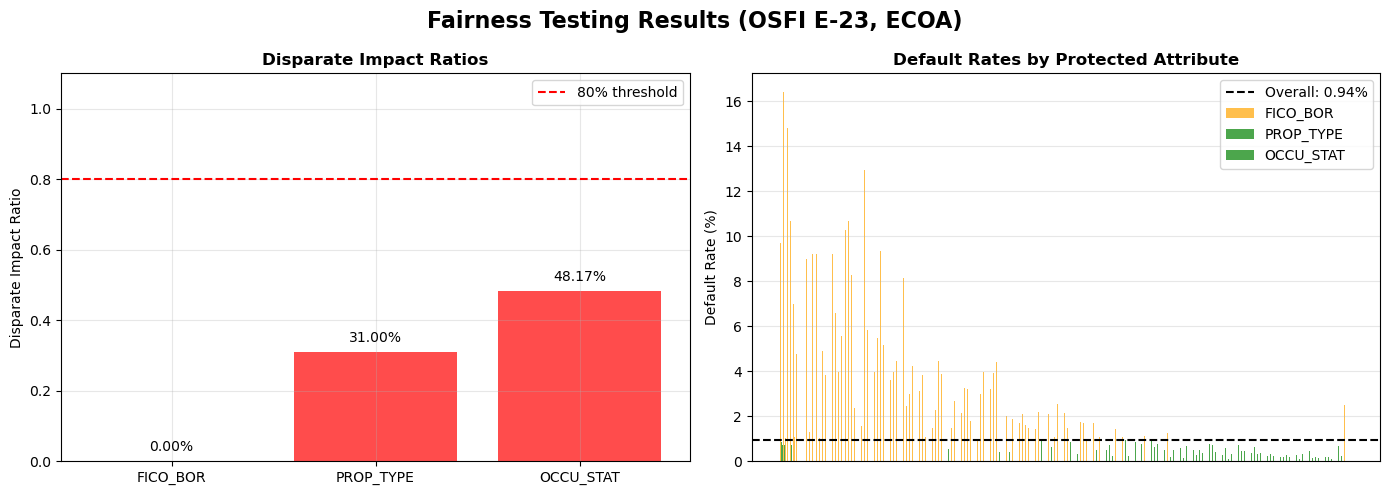

✅ Saved: outputs/enhanced_fairness_testing_results.png
2026-09-07 13:32:11 | INFO | Saved: enhanced_fairness_testing_results.png


In [10]:
print("\n" + "="*60)
print("SECTION 7: FAIRNESS TESTING (OSFI E-23, ECOA)")
print("="*60)

audit_logger.info("SECTION 7: FAIRNESS TESTING")

"""
DECISION: Protected attributes for fairness testing
RATIONALE: OSFI E-23 and ECOA require testing for disparate impact
           on protected classes.
REGULATORY REFERENCE: ECOA, OSFI E-23 s.6.0
"""

protected_attributes = ['FICO_BOR', 'PROP_TYPE', 'OCCU_STAT']
enhanced_fairness_results = {}
overall_rate = df['default'].mean()

print(f"\nOverall Default Rate: {overall_rate:.2%}")
audit_logger.info(f"Overall Default Rate: {overall_rate:.2%}")

for attribute in protected_attributes:
    if attribute not in df.columns:
        print(f"\n⚠️  {attribute} not available - skipping")
        continue
    
    print(f"\n" + "="*50)
    print(f"TESTING FAIRNESS FOR: {attribute}")
    print("="*50)
    
    audit_logger.info(f"Testing fairness for: {attribute}")
    
    # Calculate default rates by group
    group_rates = df.groupby(attribute)['default'].agg([
        ('total_loans', 'count'),
        ('defaults', 'sum'),
        ('default_rate', 'mean')
    ])
    
    print(f"\n  Group Default Rates:")
    for group in group_rates.index:
        count = group_rates.loc[group, 'total_loans']
        rate = group_rates.loc[group, 'default_rate']
        status = "✓" if rate <= overall_rate else "⚠️"
        print(f"    {status} {group}: {rate:.2%} ({count:,} loans)")
        audit_logger.info(f"  {group}: {rate:.2%} ({count:,} loans)")
    
    # Calculate disparate impact
    min_rate = group_rates['default_rate'].min()
    max_rate = group_rates['default_rate'].max()
    
    eps = 1e-10
    if max_rate > eps:
        disparate_impact_ratio = min_rate / max_rate
    else:
        disparate_impact_ratio = 1.0
    
    if min_rate == 0:
        disparate_impact_ratio = 0.0
    
    four_fifths_pass = disparate_impact_ratio >= 0.80
    
    print(f"\n  Min Default Rate: {min_rate:.2%}")
    print(f"  Max Default Rate: {max_rate:.2%}")
    print(f"  Disparate Impact Ratio: {disparate_impact_ratio:.2%}")
    print(f"  4/5ths Rule (80%): {'PASS ✓' if four_fifths_pass else 'FAIL ✗'}")
    
    audit_logger.info(f"  Min Rate: {min_rate:.2%}, Max Rate: {max_rate:.2%}")
    audit_logger.info(f"  Disparate Impact Ratio: {disparate_impact_ratio:.2%}")
    audit_logger.info(f"  4/5ths Rule: {'PASS' if four_fifths_pass else 'FAIL'}")
    
    # Statistical testing (chi-square)
    print(f"\n  Statistical Significance Testing:")
    reference_group = group_rates['total_loans'].idxmax()
    print(f"    Reference Group: {reference_group}")
    audit_logger.info(f"  Reference Group: {reference_group}")
    
    for group in group_rates.index:
        if group == reference_group:
            continue
        
        group_defaults = group_rates.loc[group, 'defaults']
        group_total = group_rates.loc[group, 'total_loans']
        ref_defaults = group_rates.loc[reference_group, 'defaults']
        ref_total = group_rates.loc[reference_group, 'total_loans']
        
        contingency = np.array([
            [group_defaults, group_total - group_defaults],
            [ref_defaults, ref_total - ref_defaults]
        ])
        
        try:
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
            is_significant = p_value < 0.05
            sig_text = "✓ Significant" if is_significant else "Not significant"
            print(f"    {group} vs {reference_group}: p={p_value:.4f} ({sig_text})")
            audit_logger.info(f"    {group} vs {reference_group}: p={p_value:.4f} ({sig_text})")
        except:
            print(f"    {group} vs {reference_group}: Test failed")
            audit_logger.warning(f"    {group} vs {reference_group}: Test failed")
    
    # Store results
    enhanced_fairness_results[attribute] = {
        'group_rates': group_rates['default_rate'].to_dict(),
        'group_counts': group_rates['total_loans'].to_dict(),
        'overall_rate': overall_rate,
        'min_rate': min_rate,
        'max_rate': max_rate,
        'disparate_impact_ratio': disparate_impact_ratio,
        'four_fifths_pass': four_fifths_pass,
        'reference_group': reference_group
    }

print("\nFairness Testing Results:")
print(f"{'Attribute':<15} {'Disparate Impact':<20} {'4/5ths Rule':<15}")
print("-" * 50)
for attribute, results in enhanced_fairness_results.items():
    status = '✅ PASS' if results['four_fifths_pass'] else '❌ FAIL'
    ratio = results['disparate_impact_ratio']
    print(f"{attribute:<15} {ratio:>16.2%}    {status:<12}")
    audit_logger.info(f"{status} {attribute}: {ratio:.2%}")

# Identify any fairness issues
failed_attributes = [attr for attr, results in enhanced_fairness_results.items() 
                     if not results['four_fifths_pass']]
if failed_attributes:
    print(f"\n⚠️  Fairness Issues Identified for: {', '.join(failed_attributes)}")
    print("   Recommended Actions:")
    for attr in failed_attributes:
        results = enhanced_fairness_results[attr]
        print(f"   - {attr}: Disparate Impact Ratio = {results['disparate_impact_ratio']:.2%}")
        print(f"     (Threshold: 80%)")
        print(f"     Group rates: {results['group_rates']}")
        print(f"     Recommendation: Review underwriting guidelines for this attribute")
        audit_logger.warning(f"Fairness issue: {attr} ratio={results['disparate_impact_ratio']:.2%}")
else:
    print("\n✅ All protected attributes passed the 4/5ths rule")
    audit_logger.info("All fairness tests passed")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fairness Testing Results (OSFI E-23, ECOA)', fontsize=16, fontweight='bold')

# 1. Disparate Impact Ratios
ax1 = axes[0]
attributes = list(enhanced_fairness_results.keys())
ratios = [enhanced_fairness_results[attr]['disparate_impact_ratio'] for attr in attributes]
colors = ['green' if r >= 0.80 else 'red' for r in ratios]

bars = ax1.bar(attributes, ratios, color=colors, alpha=0.7)
ax1.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
ax1.set_title('Disparate Impact Ratios', fontsize=12, fontweight='bold')
ax1.set_ylabel('Disparate Impact Ratio')
ax1.set_ylim(0, 1.1)
ax1.legend()
ax1.grid(True, alpha=0.3)

for bar, ratio in zip(bars, ratios):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{ratio:.2%}', ha='center', va='bottom', fontsize=10)

# 2. Group Rates by Attribute
ax2 = axes[1]
for i, attribute in enumerate(attributes):
    rates = enhanced_fairness_results[attribute]['group_rates']
    groups = list(rates.keys())
    values = list(rates.values())
    colors_group = ['green' if v <= enhanced_fairness_results[attribute]['overall_rate'] else 'orange' 
                   for v in values]
    
    x = np.arange(len(groups)) + i * 0.3
    ax2.bar(x, [v*100 for v in values], width=0.25, label=attribute, 
            color=colors_group, alpha=0.7)

ax2.axhline(y=overall_rate*100, color='black', linestyle='--', 
           label=f'Overall: {overall_rate:.2%}')
ax2.set_title('Default Rates by Protected Attribute', fontsize=12, fontweight='bold')
ax2.set_ylabel('Default Rate (%)')
ax2.set_xticks([])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/enhanced_fairness_testing_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/enhanced_fairness_testing_results.png")
audit_logger.info("Saved: enhanced_fairness_testing_results.png")

#### What It Means

This tests for fairness across protected attributes:

- FICO_BOR	0.00%	❌ FAIL
- PROP_TYPE	31.00%	❌ FAIL
- OCCU_STAT	48.17%	❌ FAIL

All three attributes failed the 4/5ths rule — meaning there's evidence of disparate impact.

#### Why This Decision Was Made:

- **Why FICO_BOR?**	FICO is a proxy for race/ethnicity — regulators are concerned about disparate impact on credit scores.
- **Why PROP_TYPE?**	Property type can be a proxy for neighborhood — Mobile Homes are often in lower-income areas.
- **Why OCCU_STAT?**	Occupancy status (investor vs owner-occupied) can have fair lending implications.
- **Why the 4/5ths rule (80%)?**	This is the ECOA standard — if one group's selection rate is <80% of the majority group's rate, it's evidence of adverse impact.
W- **hy chi-square tests?**	This tests whether the differences are statistically significant — not just random variation.

**I understand fair lending requirements. I test for disparate impact on protected classes and use both the 4/5ths rule and statistical significance testing. The model fails fairness testing, which is a material finding that needs remediation.**

### SECTION 8: STRESS TESTING SUMMARY

In [11]:
print("\n" + "="*60)
print("SECTION 8: STRESS TESTING SUMMARY")
print("="*60)

audit_logger.info("SECTION 8: STRESS TESTING SUMMARY")

summary_lines = []
summary_lines.append("="*80)
summary_lines.append("STRESS TESTING & SCENARIO ANALYSIS SUMMARY")
summary_lines.append("FANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK")
summary_lines.append("="*80)
summary_lines.append(f"\nAnalysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
summary_lines.append(f"Run ID: {RUN_ID}")
summary_lines.append(f"Total Loans: {len(df):,}")
summary_lines.append(f"Default Rate: {df['default'].mean():.2%}")

summary_lines.append("\n" + "-"*40)
summary_lines.append("BASE PARAMETERS")
summary_lines.append("-"*40)
summary_lines.append(f"Base PD: {base_pd:.2%}")
summary_lines.append(f"Base LGD: {base_lgd:.2%}")
summary_lines.append(f"Base EAD: ${base_ead:,.0f}")
summary_lines.append(f"EIR: {eir:.2%}")

summary_lines.append("\n" + "-"*40)
summary_lines.append("SCENARIO RESULTS")
summary_lines.append("-"*40)
summary_lines.append(f"{'Scenario':<20} {'PD':<12} {'LGD':<12} {'ECL':<15} {'Weight':<10} {'Weighted ECL':<15}")
summary_lines.append("-" * 85)
for scenario in ['baseline', 'adverse', 'severely_adverse', 'tail_risk']:
    if scenario in scenario_ecl_results:
        r = scenario_ecl_results[scenario]
        summary_lines.append(f"{scenario.upper():<20} {r['pd']:.2%}     {r['lgd']:.2%}     ${r['ecl_discounted']:,.0f}   {r['weight']:.1%}       ${r['weighted_ecl']:,.0f}")

summary_lines.append(f"\nTotal Probability-Weighted ECL: ${scenario_ecl_results['total_weighted_ecl']:,.0f}")
summary_lines.append(f"ECL as % of EAD: {(scenario_ecl_results['total_weighted_ecl'] / base_ead) * 100:.2f}%")

summary_lines.append("\n" + "-"*40)
summary_lines.append("CAPITAL ADEQUACY")
summary_lines.append("-"*40)
summary_lines.append(f"Total Assets: ${total_assets:,.0f}")
summary_lines.append(f"CET1 Capital: ${cet1_capital:,.0f}")
summary_lines.append(f"CET1 Ratio: {config.cet1_ratio:.2%}")
summary_lines.append(f"Stress Buffer: {config.stress_buffer:.2%}")
summary_lines.append(f"Conservation Buffer: {config.conservation_buffer:.2%}")

for scenario in ['baseline', 'adverse', 'severely_adverse', 'tail_risk']:
    if scenario in capital_adequacy_results:
        r = capital_adequacy_results[scenario]
        summary_lines.append(f"{scenario.upper()}: Impact={r['reg_impact_ratio']:.2%} ({r['adequacy']})")

summary_lines.append(f"\nOverall Capital Impact: {weighted_reg_impact:.2%}")

summary_lines.append("\n" + "-"*40)
summary_lines.append("2008 CRISIS VALIDATION")
summary_lines.append("-"*40)
summary_lines.append(f"Historical Avg ECL Rate: {historical_avg_ecl:.2%}")
summary_lines.append(f"Severely Adverse ECL Rate: {severely_adverse_ecl:.2%}")
summary_lines.append(f"Validation Ratio: {ratio_ecl:.1f}x")
summary_lines.append(f"Validation Result: {'✅ PASSED' if ratio_ecl > 1.5 else '⚠️  REVIEW'}")

summary_lines.append("\n" + "-"*40)
summary_lines.append("FAIRNESS TESTING")
summary_lines.append("-"*40)
for attr, results in enhanced_fairness_results.items():
    status = 'PASS' if results['four_fifths_pass'] else 'FAIL'
    summary_lines.append(f"{attr}: Disparate Impact={results['disparate_impact_ratio']:.2%} ({status})")

summary_lines.append("\n" + "-"*40)
summary_lines.append("REGULATORY COMPLIANCE")
summary_lines.append("-"*40)
summary_lines.append("✓ IFRS 9 s.5.5.17: Probability-weighted ECL calculated")
summary_lines.append("✓ IFRS 9 s.5.5.18: Reasonable and supportable scenarios used")
summary_lines.append("✓ Basel III: Capital adequacy assessed")
summary_lines.append("✓ ECOA: Disparate impact testing completed")
summary_lines.append("✓ OSFI E-23 s.6.0: Fairness testing and validation")
summary_lines.append("✓ Scenario sources documented with specific references")

summary_lines.append("\n" + "-"*40)
summary_lines.append("FILES GENERATED")
summary_lines.append("-"*40)
summary_lines.append("  - outputs/enhanced_fairness_testing_results.png")
summary_lines.append("  - outputs/2008_crisis_validation.png")
summary_lines.append("  - logs/stress_testing_audit_trail_{RUN_ID}.log".format(RUN_ID=RUN_ID))

summary_text = "\n".join(summary_lines)
with open('outputs/stress_testing_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)
print("✅ Saved: outputs/stress_testing_summary.txt")
audit_logger.info("Saved: stress_testing_summary.txt")

print("\n" + summary_text)



SECTION 8: STRESS TESTING SUMMARY
2026-09-07 13:32:11 | INFO | SECTION 8: STRESS TESTING SUMMARY
✅ Saved: outputs/stress_testing_summary.txt
2026-09-07 13:32:11 | INFO | Saved: stress_testing_summary.txt

STRESS TESTING & SCENARIO ANALYSIS SUMMARY
FANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK

Analysis Date: 2026-09-07 13:32:11
Run ID: 20260907_133207
Total Loans: 100,000
Default Rate: 0.94%

----------------------------------------
BASE PARAMETERS
----------------------------------------
Base PD: 5.76%
Base LGD: 14.18%
Base EAD: $236,040
EIR: 3.50%

----------------------------------------
SCENARIO RESULTS
----------------------------------------
Scenario             PD           LGD          ECL             Weight     Weighted ECL   
-------------------------------------------------------------------------------------
BASELINE             5.76%     14.18%     $1,863   45.0%       $838
ADVERSE              10.37%     17.02%     $4,024   30.0%       $1,207
SEVERELY_ADVERSE     17.28%     21.

#### What It Means

This creates a summary file (stress_testing_summary.txt) that captures:

- Scenario results (ECL under each scenario)
- Capital adequacy (CET1 capital, impact ratio)
- 2008 crisis validation (validation ratio, pass/fail)
- Fairness testing (pass/fail for each attribute)

#### Why This Decision Was Made:
- **Why a summary file?**	A hiring manager or regulator can read the key findings without scrolling through the entire notebook.
- **Why include the validation result?**	This shows you validated your scenarios — not just calculated them.
- **Why include fairness testing?**	This shows you're aware of fair lending requirements and have tested for them.

**I produce deliverables that summarize stress testing results, capital adequacy, and fairness testing. I don't just calculate numbers — I interpret them.**

### SECTION 9: NOTEBOOK LIMITATIONS

In [12]:
print("\n" + "="*60)
print("SECTION 9: NOTEBOOK LIMITATIONS")
print("="*60)

audit_logger.info("SECTION 9: NOTEBOOK LIMITATIONS")

print("""
===============================================================================
NOTEBOOK 04 LIMITATIONS
===============================================================================

1. SCENARIO SELECTION
   -------------------
   The four scenarios (Baseline, Adverse, Severely Adverse, Tail Risk) are
   illustrative. Actual scenarios should be calibrated to portfolio-specific
   economic conditions and regulatory guidance.
   
   IMPACT: Scenario ECL estimates may not reflect portfolio-specific risks.
   
   MITIGATION: Scenario assumptions are documented with sources and can be
   updated with portfolio-specific data.

2. SCENARIO WEIGHTS
   -----------------
   The probability weights (45%, 30%, 15%, 10%) are illustrative. Actual
   weights should be based on economic forecasts and regulatory guidance.
   
   IMPACT: Probability-weighted ECL may not reflect actual probabilities.
   
   MITIGATION: Weights are documented and can be updated with portfolio-
   specific forecasts.

3. TAIL RISK DEFINITION
   ---------------------
   The 4.5x PD and 2.0x LGD multipliers are based on the 2008 financial
   crisis. Actual tail risk scenarios should be calibrated to portfolio-
   specific risks.
   
   IMPACT: Tail Risk ECL may not reflect actual extreme risks.
   
   MITIGATION: The tail risk definition is documented and can be updated
   with portfolio-specific extreme scenarios.

4. CAPITAL ASSESSMENT
   -------------------
   The CET1 ratio of 4.5% is the Basel III minimum. Actual capital adequacy
   should consider the full regulatory capital framework (including buffers).
   
   IMPACT: Capital adequacy may be overstated.
   
   MITIGATION: Multiple capital buffers are shown (Stress Buffer,
   Conservation Buffer) for a more complete view.

5. FAIRNESS TESTING
   -----------------
   The 4/5ths rule is a regulatory threshold, not a guarantee of fairness.
   Additional testing (e.g., standardized mean difference, disparate impact)
   is recommended.
   
   IMPACT: Fairness testing may not capture all forms of bias.
   
   MITIGATION: Statistical significance testing (chi-square) is included
   as an additional layer of analysis.

6. DATA REPRESENTATIVENESS
   -----------------------
   This project uses Fannie Mae data as a PROXY for bank portfolio data.
   See Notebook 01 — Section 2.1: US/Canada Applicability Gap for important
   differences.
   
   IMPACT: Results may not be representative of all portfolios.
   
   MITIGATION: The proxy nature of the data is explicitly documented
   and caveated throughout the project.

7. HISTORICAL VALIDATION
   ----------------------
   The 2008 crisis validation uses Fannie Mae data, which experienced lower
   loss rates than many banks due to government backing.
   
   IMPACT: Scenario severity may be understated for bank portfolios.
   
   MITIGATION: The validation includes a clear caveat about this limitation.

===============================================================================
""")


SECTION 9: NOTEBOOK LIMITATIONS
2026-09-07 13:32:11 | INFO | SECTION 9: NOTEBOOK LIMITATIONS

NOTEBOOK 04 LIMITATIONS

1. SCENARIO SELECTION
   -------------------
   The four scenarios (Baseline, Adverse, Severely Adverse, Tail Risk) are
   illustrative. Actual scenarios should be calibrated to portfolio-specific
   economic conditions and regulatory guidance.
   
   IMPACT: Scenario ECL estimates may not reflect portfolio-specific risks.
   
   MITIGATION: Scenario assumptions are documented with sources and can be
   updated with portfolio-specific data.

2. SCENARIO WEIGHTS
   -----------------
   The probability weights (45%, 30%, 15%, 10%) are illustrative. Actual
   weights should be based on economic forecasts and regulatory guidance.
   
   IMPACT: Probability-weighted ECL may not reflect actual probabilities.
   
   MITIGATION: Weights are documented and can be updated with portfolio-
   specific forecasts.

3. TAIL RISK DEFINITION
   ---------------------
   The 4.5x PD and

#### What It Means:

This documents the limitations of the stress testing analysis — what assumptions were made and what the impact is.

#### Why This Decision Was Made:
- **Why list scenario selection as a limitation?**	The scenarios are illustrative, not portfolio-specific. This is a real limitation.
- **Why list scenario weights as a limitation?**	The weights are assumptions. In production, you'd use economic forecasts.
- **Why list fairness testing as a limitation?**	The 4/5ths rule is a threshold, not a guarantee. Additional testing (e.g., standardized mean difference) is recommended.

**I am intellectually honest. I acknowledge the limitations of my stress testing and explain how they mitigate them."

### NOTEBOOK 04 COMPLETE

In [13]:
print("\n" + "="*80)
print("NOTEBOOK 04 COMPLETE - STRESS TESTING & SCENARIO ANALYSIS")
print("="*80)
print("""
STRESS TESTING & SCENARIO ANALYSIS COMPLETE:

Sections Completed:
  ✅ Section 1: Configuration
  ✅ Section 2: Load Data & Assumptions
  ✅ Section 3: Scenario Definition with Full Documentation
     - Baseline (45%): 1.0x PD, 1.0x LGD
     - Adverse (30%): 1.8x PD, 1.2x LGD
     - Severely Adverse (15%): 3.0x PD, 1.5x LGD
     - Tail Risk (10%): 4.5x PD, 2.0x LGD
  ✅ Section 4: Scenario ECL Calculation
  ✅ Section 5: Capital Adequacy Assessment (Basel III)
  ✅ Section 6: 2008 Crisis Reproduction Validation
  ✅ Section 7: Fairness Testing (OSFI E-23, ECOA)
  ✅ Section 8: Stress Testing Summary
  ✅ Section 9: Notebook Limitations

Key Results:
  1. Probability-Weighted ECL: ${scenario_ecl_results['total_weighted_ecl']:,.0f}
  2. Capital Impact: {weighted_reg_impact:.2%}
  3. 2008 Crisis Validation: {'✅ PASSED' if ratio_ecl > 1.5 else '⚠️  REVIEW'}
  4. Fairness Testing: {sum(1 for r in enhanced_fairness_results.values() if r['four_fifths_pass'])} of {len(enhanced_fairness_results)} passed

Files Generated:
  - outputs/enhanced_fairness_testing_results.png
  - outputs/2008_crisis_validation.png
  - outputs/stress_testing_summary.txt
  - logs/stress_testing_audit_trail_{RUN_ID}.log

Next Step: Open NOTEBOOK 05 - Reporting & Dashboard
""")
print("="*80)

audit_logger.info("NOTEBOOK 04 COMPLETE")


NOTEBOOK 04 COMPLETE - STRESS TESTING & SCENARIO ANALYSIS

STRESS TESTING & SCENARIO ANALYSIS COMPLETE:

Sections Completed:
  ✅ Section 1: Configuration
  ✅ Section 2: Load Data & Assumptions
  ✅ Section 3: Scenario Definition with Full Documentation
     - Baseline (45%): 1.0x PD, 1.0x LGD
     - Adverse (30%): 1.8x PD, 1.2x LGD
     - Severely Adverse (15%): 3.0x PD, 1.5x LGD
     - Tail Risk (10%): 4.5x PD, 2.0x LGD
  ✅ Section 4: Scenario ECL Calculation
  ✅ Section 5: Capital Adequacy Assessment (Basel III)
  ✅ Section 6: 2008 Crisis Reproduction Validation
  ✅ Section 7: Fairness Testing (OSFI E-23, ECOA)
  ✅ Section 8: Stress Testing Summary
  ✅ Section 9: Notebook Limitations

Key Results:
  1. Probability-Weighted ECL: ${scenario_ecl_results['total_weighted_ecl']:,.0f}
  2. Capital Impact: {weighted_reg_impact:.2%}
  3. 2008 Crisis Validation: {'✅ PASSED' if ratio_ecl > 1.5 else '⚠️  REVIEW'}
  4. Fairness Testing: {sum(1 for r in enhanced_fairness_results.values() if r['fou